# Prevalência de GenAI e anúncios de vagas de desenvolvimento de software

**Pergunta de pesquisa:** A prevalência de linguagem relacionada à IA generativa ajuda a explicar a variação no índice de anúncios de Software Development do Indeed nos EUA, depois de considerar as condições gerais de contratação?

**Unidade de observação:** um mês-calendário de novembro de 2022 a maio de 2025.
**Resposta (Y):** índice de todos os anúncios de Software Development, um índice contínuo em que 1º de fevereiro de 2020 = 100.
**Preditores:** proporção de anúncios relacionados à GenAI em pontos percentuais (X1) e índice dessazonalizado de todos os anúncios (X2).

### Hipóteses registradas antes da modelagem

1. A inclinação bruta da proporção de GenAI será negativa, porque a prevalência de GenAI aumenta enquanto a contratação em tecnologia esfria.
2. Controlar pelo mercado geral de anúncios mudará substancialmente o coeficiente de GenAI.
3. Um polinômio de grau 2 acrescentará pouca melhora confiável no teste com apenas 21 meses de treinamento.
4. As primeiras diferenças enfraquecerão o resultado em nível se tendências temporais comuns determinarem a associação.

A análise é observacional. Ela não afirma que a IA cause perda ou crescimento de empregos.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

ROOT = Path.cwd()
if ROOT.name != "genai_jobs":
    ROOT = Path("cp4/genai_jobs")
RAW = ROOT / "data" / "raw"
START, END = "2022-11-01", "2025-05-31"
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)


def format_month_axis(ax, interval=4):
    """Mostra menos rótulos YYYY-MM, de forma legível, nos eixos de data."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

assert RAW.exists(), f"Pasta de dados brutos não encontrada: {RAW}"

## 1. Fontes, dicionário de dados e plano de preparação

Os dados públicos vêm do [Indeed Hiring Lab AI Tracker](https://github.com/hiring-lab/ai-tracker) e do [Job Postings Tracker](https://github.com/hiring-lab/job_postings_tracker), acessados em 27/08/2026. O CSV histórico de GenAI está fixado no commit `073a8db`; os dados gerados são documentados sob CC BY 4.0.

| Variável | Tipo / unidade | Papel | Definição |
|---|---|---|---|
| `software_postings_index` | Índice contínuo | Y | Índice de todos os anúncios de Software Development |
| `genai_share_pct` | Pontos percentuais | X1 | Proporção de anúncios contendo linguagem relacionada à GenAI |
| `total_postings_index_sa` | Índice contínuo | X2 | Índice dessazonalizado de todos os anúncios nos EUA |
| `month_start` | Data | Chave | Primeiro dia do mês agregado |

A auditoria abaixo verifica dimensões originais, tipos de dados, valores ausentes, linhas duplicadas, meses finais duplicados e marcações IQR da resposta antes da modelagem.

In [2]:
genai_raw = pd.read_csv(RAW / "GenAI_posting.csv", parse_dates=["date"])
sector_raw = pd.read_csv(RAW / "job_postings_by_sector_US.csv", parse_dates=["date"])
total_raw = pd.read_csv(RAW / "aggregate_job_postings_US.csv", parse_dates=["date"])

raw_frames = {
    "GenAI_posting.csv": genai_raw,
    "job_postings_by_sector_US.csv": sector_raw,
    "aggregate_job_postings_US.csv": total_raw,
}
raw_audit = pd.DataFrame([
    {
        "file": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "duplicate_rows": int(frame.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "dtypes": ", ".join(f"{column}:{dtype}" for column, dtype in frame.dtypes.items()),
    }
    for name, frame in raw_frames.items()
])

genai = genai_raw.loc[
    (genai_raw.jobcountry == "US") & genai_raw.date.between(START, END),
    ["date", "GenAI_share_postings"],
].copy()
software = sector_raw.loc[
    (sector_raw.jobcountry == "US")
    & (sector_raw.display_name == "Software Development")
    & (sector_raw.variable == "total postings")
    & sector_raw.date.between(START, END),
    ["date", "indeed_job_postings_index"],
].copy()
all_postings = total_raw.loc[
    (total_raw.jobcountry == "US")
    & (total_raw.variable == "total postings")
    & total_raw.date.between(START, END),
    ["date", "indeed_job_postings_index_SA"],
].copy()

for frame in (genai, software, all_postings):
    frame["month"] = frame.date.dt.to_period("M")

monthly = (
    genai.groupby("month", as_index=False).GenAI_share_postings.mean()
    .merge(
        software.groupby("month", as_index=False).indeed_job_postings_index.mean(),
        on="month",
    )
    .merge(
        all_postings.groupby("month", as_index=False).indeed_job_postings_index_SA.mean(),
        on="month",
    )
    .rename(
        columns={
            "GenAI_share_postings": "genai_share_pct",
            "indeed_job_postings_index": "software_postings_index",
            "indeed_job_postings_index_SA": "total_postings_index_sa",
        }
    )
    .sort_values("month")
    .reset_index(drop=True)
)
monthly["genai_share_pct"] = monthly["genai_share_pct"] * 100
monthly["month_start"] = monthly.month.dt.to_timestamp()
monthly["month_label"] = monthly.month.astype(str)
monthly["time_index"] = np.arange(len(monthly))

q1, q3 = monthly.software_postings_index.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_flags = monthly.loc[
    ~monthly.software_postings_index.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr),
    ["month_label", "software_postings_index"],
]

print("Linhas diárias filtradas:", len(genai), len(software), len(all_postings))
print("Dimensão final:", monthly.shape)
print("Células ausentes finais:", int(monthly.isna().sum().sum()))
print("Meses duplicados:", int(monthly.month.duplicated().sum()))
print("Marcações IQR da resposta (mantidas; sem exclusão automática):")
display(iqr_flags)
display(raw_audit)
display(monthly.head())

Linhas diárias filtradas: 943 943 943
Dimensão final: (31, 7)
Células ausentes finais: 0
Meses duplicados: 0
Marcações IQR da resposta (mantidas; sem exclusão automática):


,month_label,software_postings_index
0,2022-11,147.085667
1,2022-12,135.289677
2,2023-01,126.327742
3,2023-02,114.172143


,file,rows,columns,duplicate_rows,missing_cells,dtypes
0,GenAI_posting.csv,21339,3,0,0,"date:datetime64[us], jobcountry:str, GenAI_sha..."
1,job_postings_by_sector_US.csv,210672,5,0,0,"date:datetime64[us], jobcountry:str, indeed_jo..."
2,aggregate_job_postings_US.csv,4788,5,0,0,"date:datetime64[us], jobcountry:str, indeed_jo..."


,month,genai_share_pct,software_postings_index,total_postings_index_sa,month_start,month_label,time_index
0,2022-11,0.411323,147.085667,147.735000,2022-11-01,2022-11,0
1,2022-12,0.492195,135.289677,144.420645,2022-12-01,2022-12,1
2,2023-01,0.619967,126.327742,140.582258,2023-01-01,2023-01,2
3,2023-02,0.886103,114.172143,136.573571,2023-02-01,2023-02,3
4,2023-03,0.931217,102.560000,134.952258,2023-03-01,2023-03,4


## 2. Decisões de preparação e requisitos exploratórios

- Datas e rótulos de seleção são convertidos explicitamente; nenhum valor numérico permanece armazenado como texto após o carregamento.
- A janela comum dos EUA e a definição consistente de `total postings` são usadas em todas as fontes.
- As observações diárias são calculadas como médias por mês-calendário e depois combinadas por mês.
- A fração bruta de GenAI é multiplicada por 100 exatamente uma vez para obter pontos percentuais.
- Não são necessários imputação, escalonamento, codificação categórica ou exclusão de linhas.
- As marcações IQR são mantidas porque os valores altos dos primeiros meses são observações cronológicas legítimas, não erros de registro.
- Não há preditores categóricos no modelo final.

Após a filtragem, cada série do Indeed contém 943 registros diários alinhados. São medições de três variáveis nas mesmas datas, e não 2.829 casos independentes. A regressão usa deliberadamente 31 meses-calendário como unidade de observação. A agregação mensal corresponde à pergunta de pesquisa e à comparação do HN, reduz o ruído diário e evita superestimar a precisão tratando dias adjacentes fortemente autocorrelacionados como evidência independente. A preferência da atividade por 100 observações, portanto, não é atendida pela amostra da regressão; a incerteza da amostra pequena é incorporada à seleção de modelos, aos diagnósticos e às limitações.

A análise exploratória inclui estatísticas e distribuição da resposta, dados ausentes, tendências temporais, gráfico de dispersão quantitativo, correlações e discussão de assimetria, extremos e possível não linearidade.

,Contagem,Média,Desvio-padrão,Mínimo,25%,Mediana,75%,Máximo
genai_share_pct,31.0,11.812124,9.173312,0.411323,2.820303,10.901279,19.989546,26.886492
software_postings_index,31.0,81.435388,22.169489,62.323226,68.571613,71.136552,85.256027,147.085667
total_postings_index_sa,31.0,121.776877,11.956505,105.886452,111.343344,118.576129,130.615575,147.735000


,genai_share_pct,software_postings_index,total_postings_index_sa
genai_share_pct,1.000,-0.750,-0.942
software_postings_index,-0.750,1.000,0.915
total_postings_index_sa,-0.942,0.915,1.000


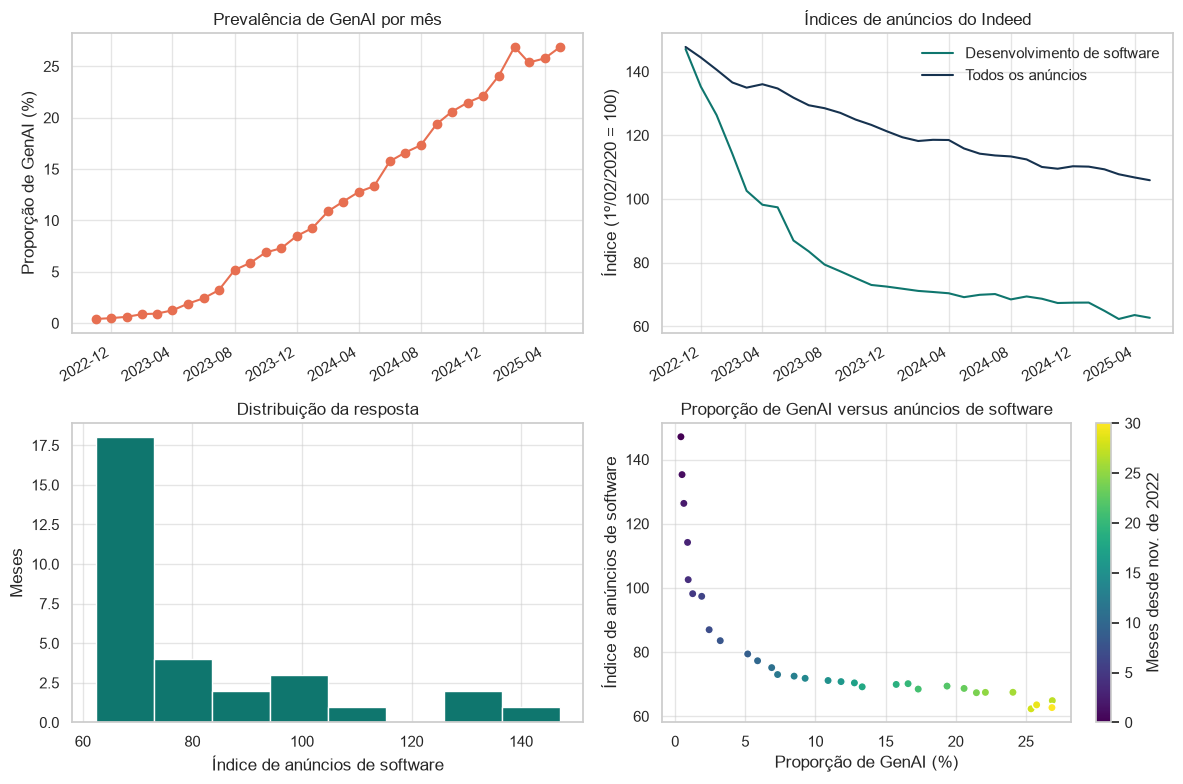

Interpretação: a resposta tem assimetria à direita porque os primeiros meses têm índices altos. O gradiente de cores mostra que a associação negativa bruta é fortemente ordenada no tempo. A proporção de GenAI e o controle de todos os anúncios também se movem em direções opostas; por isso, a colinearidade e a sensibilidade à tendência comum precisam ser examinadas.


In [3]:
variables = ["genai_share_pct", "software_postings_index", "total_postings_index_sa"]
display(
    monthly[variables].describe().T.rename(
        columns={
            "count": "Contagem",
            "mean": "Média",
            "std": "Desvio-padrão",
            "min": "Mínimo",
            "50%": "Mediana",
            "max": "Máximo",
        }
    )
)
display(monthly[variables].corr().round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(monthly.month_start, monthly.genai_share_pct, marker="o", color="#e76f51")
axes[0, 0].set(title="Prevalência de GenAI por mês", ylabel="Proporção de GenAI (%)")
axes[0, 1].plot(monthly.month_start, monthly.software_postings_index, label="Desenvolvimento de software", color="#0f766e")
axes[0, 1].plot(monthly.month_start, monthly.total_postings_index_sa, label="Todos os anúncios", color="#16324f")
axes[0, 1].set(title="Índices de anúncios do Indeed", ylabel="Índice (1º/02/2020 = 100)")
axes[0, 1].legend(frameon=False)
axes[1, 0].hist(monthly.software_postings_index, bins=8, color="#0f766e", edgecolor="white")
axes[1, 0].set(title="Distribuição da resposta", xlabel="Índice de anúncios de software", ylabel="Meses")
scatter = axes[1, 1].scatter(
    monthly.genai_share_pct,
    monthly.software_postings_index,
    c=monthly.time_index,
    cmap="viridis",
    edgecolor="white",
)
axes[1, 1].set(
    title="Proporção de GenAI versus anúncios de software",
    xlabel="Proporção de GenAI (%)",
    ylabel="Índice de anúncios de software",
)
fig.colorbar(scatter, ax=axes[1, 1], label="Meses desde nov. de 2022")
format_month_axis(axes[0, 0], interval=4)
format_month_axis(axes[0, 1], interval=4)
fig.tight_layout()
plt.show()

print(
    "Interpretação: a resposta tem assimetria à direita porque os primeiros meses têm índices altos. "
    "O gradiente de cores mostra que a associação negativa bruta é fortemente ordenada no tempo. "
    "A proporção de GenAI e o controle de todos os anúncios também se movem em direções opostas; "
    "por isso, a colinearidade e a sensibilidade à tendência comum precisam ser examinadas."
)

,Modelo,MAE fora da amostra,RMSE fora da amostra,R² fora da amostra
0,Média de referência,22.454589,22.592300,-81.278762
1,Linear simples,34.231415,35.332054,-200.235516
2,Linear controlado,10.592995,12.847919,-25.609239
3,Polinomial de grau 2,15.257944,21.446718,-73.146144


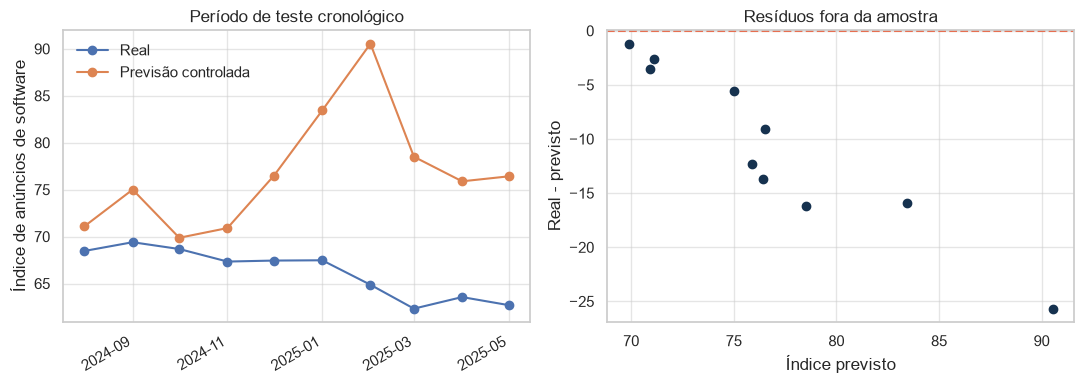

Seleção: o modelo linear controlado tem o menor MAE e RMSE no teste. Todos os R² de teste são negativos porque os dez meses finais contêm pouca variação na resposta; isso alerta que o desempenho preditivo absoluto é frágil.


In [4]:
simple_features = ["genai_share_pct"]
controlled_features = ["genai_share_pct", "total_postings_index_sa"]
cut = int(len(monthly) * 0.70)
train, test = monthly.iloc[:cut].copy(), monthly.iloc[cut:].copy()

def metric_row(name, actual, predicted):
    return {
        "model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

simple_model = LinearRegression().fit(train[simple_features], train.software_postings_index)
controlled_model = LinearRegression().fit(train[controlled_features], train.software_postings_index)
polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(2, include_bias=False)),
    ("linear", LinearRegression()),
]).fit(train[controlled_features], train.software_postings_index)

test_predictions = test[["month_start", "month_label", "software_postings_index"]].rename(
    columns={"software_postings_index": "actual"}
)
test_predictions["Reference mean"] = train.software_postings_index.mean()
test_predictions["Simple linear"] = simple_model.predict(test[simple_features])
test_predictions["Controlled linear"] = controlled_model.predict(test[controlled_features])
test_predictions["Polynomial degree 2"] = polynomial_model.predict(test[controlled_features])
test_predictions["controlled_residual"] = (
    test_predictions.actual - test_predictions["Controlled linear"]
)

comparison = pd.DataFrame([
    metric_row(name, test_predictions.actual, test_predictions[name])
    for name in ["Reference mean", "Simple linear", "Controlled linear", "Polynomial degree 2"]
])
comparison_display = comparison.rename(columns={"model": "Modelo", "MAE": "MAE fora da amostra", "RMSE": "RMSE fora da amostra", "R2": "R² fora da amostra"}).replace({"Modelo": {"Reference mean": "Média de referência", "Simple linear": "Linear simples", "Controlled linear": "Linear controlado", "Polynomial degree 2": "Polinomial de grau 2"}})
display(comparison_display)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(test_predictions.month_start, test_predictions.actual, marker="o", label="Real")
axes[0].plot(
    test_predictions.month_start,
    test_predictions["Controlled linear"],
    marker="o",
    label="Previsão controlada",
)
format_month_axis(axes[0], interval=2)
axes[0].set(title="Período de teste cronológico", ylabel="Índice de anúncios de software")
axes[0].legend(frameon=False)
axes[1].scatter(
    test_predictions["Controlled linear"],
    test_predictions.controlled_residual,
    color="#16324f",
)
axes[1].axhline(0, color="#e76f51", linestyle="--")
axes[1].set(
    title="Resíduos fora da amostra",
    xlabel="Índice previsto",
    ylabel="Real - previsto",
)
fig.tight_layout()
plt.show()

print(
    "Seleção: o modelo linear controlado tem o menor MAE e RMSE no teste. "
    "Todos os R² de teste são negativos porque os dez meses finais contêm pouca variação na resposta; "
    "isso alerta que o desempenho preditivo absoluto é frágil."
)

## 4. Coeficientes, comportamento polinomial, pressupostos e sensibilidade

A próxima célula:

- interpreta o intercepto e as duas inclinações controladas;
- lista os termos de grau 2 para mostrar que a curva inclui dois quadrados e uma interação;
- verifica correlação/VIF, linearidade dos resíduos, homocedasticidade, normalidade, independência e distância de Cook;
- usa inferência HAC/Newey-West e um modelo de sensibilidade em primeira diferença;
- reajusta a especificação selecionada com todas as observações somente após a seleção do modelo, correspondendo ao artefato serializado do Streamlit.

,Termo,Estimativa,Valor-p HAC,Interpretação
0,Intercepto,-366.158796,7.735610e-23,Previsão com os dois preditores em zero; fora ...
1,Proporção de GenAI,2.413937,1.241575e-10,Associação em pontos de índice para +1 ponto p...
2,Índice de todos os anúncios,3.441380,1.323858e-36,Associação em pontos de índice para +1 ponto d...


,Termo,VIF
0,genai_share_pct,8.672529
1,total_postings_index_sa,8.672529


,termo polinomial,coeficiente
0,genai_share_pct,93.049405
1,total_postings_index_sa,21.215326
2,genai_share_pct^2,-0.593345
3,genai_share_pct total_postings_index_sa,-0.680879
4,total_postings_index_sa^2,-0.061272


,verificação,valor
0,p de Breusch-Pagan,0.196969
1,p de Jarque-Bera,0.755791
2,Durbin-Watson,0.932994
3,limiar de Cook,0.190476
4,distância máxima de Cook,0.172264


,Mês,Índice de anúncios de software,Distância de Cook


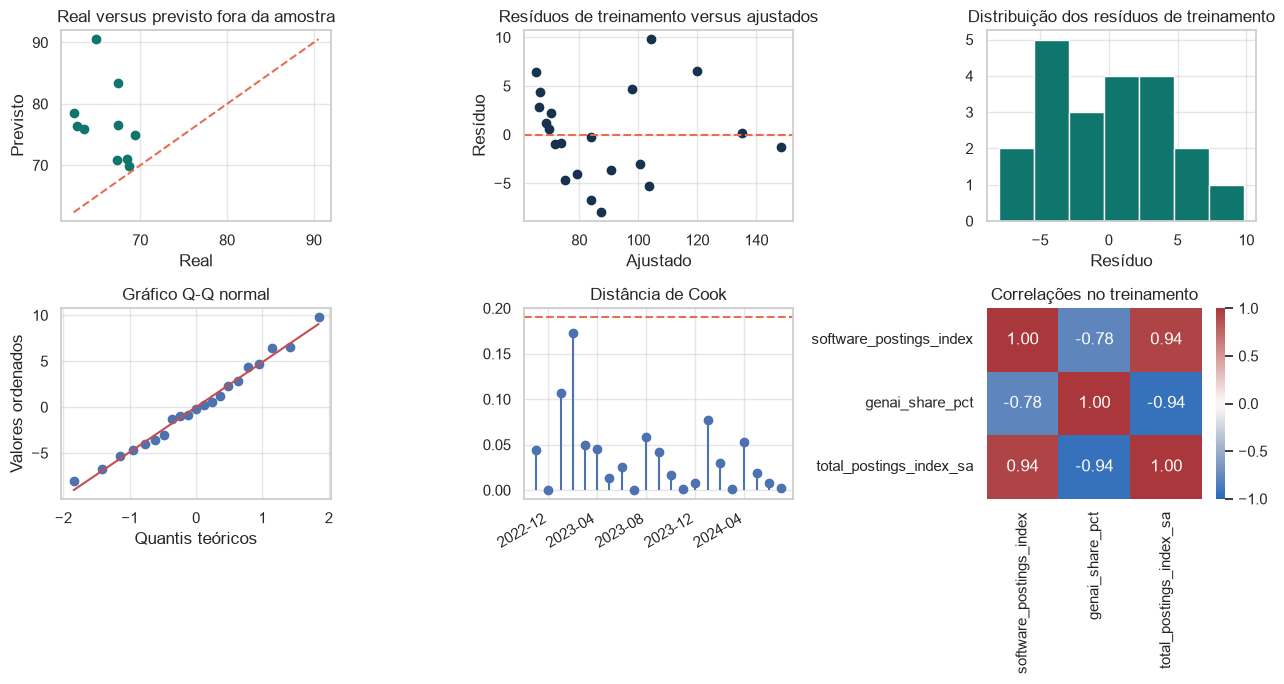

Inclinação de GenAI em nível / p HAC no simples: -1.8135542145341061 1.0784763763306137e-05
Inclinação de GenAI em nível / p HAC no controlado: 2.4139368962135337 1.2415753814788738e-10
Inclinação de GenAI na primeira diferença / p HAC: 1.3326346957352202 0.16488151651692173
O notebook e o modelo serializado coincidem: True


,Mês,Proporção de GenAI (%),Índice de todos os anúncios,Índice previsto de anúncios de software
7,2023-06,2.424659,131.805667,93.287511
23,2024-10,20.596473,110.050968,62.286945


In [5]:
level_simple = sm.OLS(
    monthly.software_postings_index,
    sm.add_constant(monthly[simple_features]),
).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
level_controlled = sm.OLS(
    monthly.software_postings_index,
    sm.add_constant(monthly[controlled_features]),
).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
changes = monthly[["software_postings_index", *controlled_features]].diff().dropna()
difference_model = sm.OLS(
    changes.software_postings_index,
    sm.add_constant(changes[controlled_features]),
).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

train_ols = sm.OLS(
    train.software_postings_index,
    sm.add_constant(train[controlled_features]),
).fit()
vif_design = sm.add_constant(train[controlled_features])
vif_table = pd.DataFrame({
    "Termo": controlled_features,
    "VIF": [
        variance_inflation_factor(vif_design.values, position)
        for position in range(1, len(vif_design.columns))
    ],
})
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(
    train_ols.resid,
    train_ols.model.exog,
)
jb = stats.jarque_bera(train_ols.resid)
cooks = train_ols.get_influence().cooks_distance[0]
cooks_threshold = 4 / len(train)

coefficient_table = pd.DataFrame({
    "Termo": ["Intercepto", "Proporção de GenAI", "Índice de todos os anúncios"],
    "Estimativa": level_controlled.params.values,
    "Valor-p HAC": level_controlled.pvalues.values,
    "Interpretação": [
        "Previsão com os dois preditores em zero; fora do suporte dos dados.",
        "Associação em pontos de índice para +1 ponto percentual de GenAI, mantendo o controle fixo.",
        "Associação em pontos de índice para +1 ponto do índice de todos os anúncios, mantendo GenAI fixa.",
    ],
})
display(coefficient_table)
display(vif_table)

poly_names = polynomial_model.named_steps["poly"].get_feature_names_out(controlled_features)
poly_coefficients = pd.DataFrame({
    "termo polinomial": poly_names,
    "coeficiente": polynomial_model.named_steps["linear"].coef_,
})
display(poly_coefficients)

diagnostic_table = pd.DataFrame({
    "verificação": ["p de Breusch-Pagan", "p de Jarque-Bera", "Durbin-Watson", "limiar de Cook", "distância máxima de Cook"],
    "valor": [bp_lm_pvalue, jb.pvalue, durbin_watson(train_ols.resid), cooks_threshold, cooks.max()],
})
display(diagnostic_table)
display(
    train.loc[cooks > cooks_threshold, ["month_label", "software_postings_index"]]
    .assign(cooks_distance=cooks[cooks > cooks_threshold])
    .rename(columns={
        "month_label": "Mês",
        "software_postings_index": "Índice de anúncios de software",
        "cooks_distance": "Distância de Cook",
    })
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes[0, 0].scatter(test_predictions.actual, test_predictions["Controlled linear"], color="#0f766e")
limits = [
    min(test_predictions.actual.min(), test_predictions["Controlled linear"].min()),
    max(test_predictions.actual.max(), test_predictions["Controlled linear"].max()),
]
axes[0, 0].plot(limits, limits, "--", color="#e76f51")
axes[0, 0].set(title="Real versus previsto fora da amostra", xlabel="Real", ylabel="Previsto")
axes[0, 1].scatter(train_ols.fittedvalues, train_ols.resid, color="#16324f")
axes[0, 1].axhline(0, color="#e76f51", linestyle="--")
axes[0, 1].set(title="Resíduos de treinamento versus ajustados", xlabel="Ajustado", ylabel="Resíduo")
axes[0, 2].hist(train_ols.resid, bins=7, color="#0f766e", edgecolor="white")
axes[0, 2].set(title="Distribuição dos resíduos de treinamento", xlabel="Resíduo")
stats.probplot(train_ols.resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set(title="Gráfico Q-Q normal", xlabel="Quantis teóricos", ylabel="Valores ordenados")
axes[1, 1].stem(train.month_start, cooks, basefmt=" ")
axes[1, 1].axhline(cooks_threshold, color="#e76f51", linestyle="--")
format_month_axis(axes[1, 1], interval=4)
axes[1, 1].set_title("Distância de Cook")
sns.heatmap(
    train[["software_postings_index", *controlled_features]].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    ax=axes[1, 2],
)
axes[1, 2].set_title("Correlações no treinamento")
fig.tight_layout()
plt.show()

print("Inclinação de GenAI em nível / p HAC no simples:", level_simple.params["genai_share_pct"], level_simple.pvalues["genai_share_pct"])
print("Inclinação de GenAI em nível / p HAC no controlado:", level_controlled.params["genai_share_pct"], level_controlled.pvalues["genai_share_pct"])
print("Inclinação de GenAI na primeira diferença / p HAC:", difference_model.params["genai_share_pct"], difference_model.pvalues["genai_share_pct"])

deployment_model = LinearRegression().fit(
    monthly[controlled_features],
    monthly.software_postings_index,
)
saved_model = joblib.load(ROOT / "model" / "controlled_linear_model.pkl")
print(
    "O notebook e o modelo serializado coincidem:",
    np.allclose(deployment_model.coef_, saved_model.coef_)
    and np.isclose(deployment_model.intercept_, saved_model.intercept_),
)

examples = monthly.iloc[[7, 23]][["month_label", *controlled_features]].copy()
examples["predicted_software_index"] = deployment_model.predict(examples[controlled_features])
display(examples.rename(columns={"month_label": "Mês", "genai_share_pct": "Proporção de GenAI (%)", "total_postings_index_sa": "Índice de todos os anúncios", "predicted_software_index": "Índice previsto de anúncios de software"}))

## 5. Resultados e conclusão

As hipóteses são apoiadas apenas em um sentido descritivo e qualificado.

### Interpretações explícitas dos coeficientes

1. **Inclinação de GenAI no modelo simples: -1,814.** Sem controlar pelo mercado mais amplo, um aumento de um ponto percentual na proporção de anúncios relacionados à GenAI está associado a cerca de 1,81 ponto a menos no índice de Software Development.
2. **Inclinação controlada de GenAI: +2,414.** Mantendo constante o índice de todos os anúncios, um aumento de um ponto percentual na proporção de GenAI está associado a cerca de 2,41 pontos adicionais no índice de Software Development. A inversão do sinal em relação ao modelo simples mostra forte confusão pela tendência geral de contratação; não é evidência de que GenAI cause crescimento de empregos.
3. **Inclinação controlada de todos os anúncios: +3,441.** Mantendo constante a proporção de GenAI, um aumento de um ponto no índice dessazonalizado de todos os anúncios está associado a cerca de 3,44 pontos adicionais no índice de Software Development.
4. **Intercepto controlado: -366,159.** É a previsão quando os dois preditores são zero. Essa combinação está muito fora dos dados observados; portanto, o intercepto é matematicamente necessário, mas não tem interpretação útil no mundo real.

### Escolha do modelo e hipóteses

- **Associação mais forte:** o índice de todos os anúncios tem a relação direta mais forte com o índice de Software Development. A proporção de GenAI e o controle também são fortemente correlacionados, portanto seus coeficientes parciais são instáveis.
- **H1 e H2:** a inclinação bruta de GenAI é negativa, mas seu sinal se inverte após o controle pelo mercado geral. O resultado depende da especificação.
- **H3:** o polinômio de grau 2 adiciona quadrados e uma interação, mas piora o MAE e o RMSE fora da amostra; o modelo controlado mais simples é selecionado.
- **H4:** o coeficiente de GenAI nas variações mensais não é estatisticamente significativo, indicando que tendências comuns explicam uma parte importante da associação em nível.
- **Erro típico com dados não utilizados:** o MAE de teste do modelo selecionado é de cerca de 10,59 pontos de índice e o RMSE, de cerca de 12,85. Seu R² de teste negativo indica baixa confiabilidade preditiva absoluta nos dez meses finais, quase estáveis.

### Dois exemplos de previsão

- Para junho de 2023, com proporção de GenAI de cerca de 2,42% e índice de todos os anúncios de 131,81, o modelo prevê um índice de Software Development de **93,29**. Isso significa um nível modelado de anúncios cerca de 6,71 pontos abaixo do valor de referência de 100 em fevereiro de 2020.
- Para outubro de 2024, com proporção de GenAI de cerca de 20,60% e índice de todos os anúncios de 110,05, o modelo prevê um índice de Software Development de **62,29**, cerca de 37,71 pontos abaixo da referência.

Esses exemplos usam combinações de preditores que realmente ocorreram nos dados. Demonstram uma saída condicional do modelo, não efeitos causais ou previsões. Entradas fora dos intervalos observados — ou combinações incomuns dentro dos intervalos individuais — seriam extrapolações e poderiam produzir previsões instáveis.

### Uso apropriado e limitações

- **Use:** educação descritiva e exploração cautelosa, dentro da amostra, de cenários com combinações de preditores historicamente plausíveis.
- **Não usar para:** atribuição causal, decisões de quadro de pessoal, previsões de vagas individuais, previsões de longo prazo ou extrapolação.
- **Limitações:** apenas 31 observações mensais do modelo, um indicador da plataforma Indeed, menções a palavras-chave em vez de adoção de IA, tendências compartilhadas fortes, correlação serial, meses influentes e variáveis macroeconômicas ou tecnológicas omitidas.
- **Melhoria:** coletar uma série histórica mais longa e adicionar juros, demissões no setor de tecnologia, produção de software, salários, duração das vagas e exposição à GenAI por ocupação; depois, usar validação com janela expansiva e modelos defasados.

**Conclusão:** a prevalência de GenAI e os níveis de anúncios de software variam conjuntamente, mas o sinal depende do ajuste pelo mercado e a associação enfraquece nas primeiras diferenças. A análise não mostra que a IA tenha causado perda ou crescimento de empregos de software.

## 6. Distribuição de senioridade no Hacker News Who Is Hiring

O suplemento descritivo usa discussões mensais `Ask HN: Who is hiring?` da [API de busca do HN](https://hn.algolia.com/api); a estrutura de itens/comentários é documentada pela [API oficial do Hacker News](https://github.com/HackerNews/API).

**Unidade:** um comentário de nível superior corresponde a uma publicação de empregador, embora um comentário possa anunciar várias funções.

Expressões regulares transparentes primeiro identificam publicações relacionadas a software e depois marcam termos de início de carreira/estágio e sênior. Publicações que correspondem aos dois vocabulários são rotuladas como mistas e contribuem para ambas as contagens de menções. A análise informa contagens brutas e proporções das publicações de software porque o volume das discussões muda ao longo do tempo. Ela não é adicionada à regressão do Indeed.

,Métrica,Primeiros 6 meses,Últimos 6 meses,Variação
0,Publicações de início de carreira/estágio por mês,17.500000,13.000000,-0.257143
1,Publicações sênior por mês,183.166667,148.166667,-0.191083
2,Proporção de início de carreira/estágio nas pu...,0.047950,0.046864,-0.001086
3,Proporção sênior nas publicações de software,0.504014,0.536071,0.032057


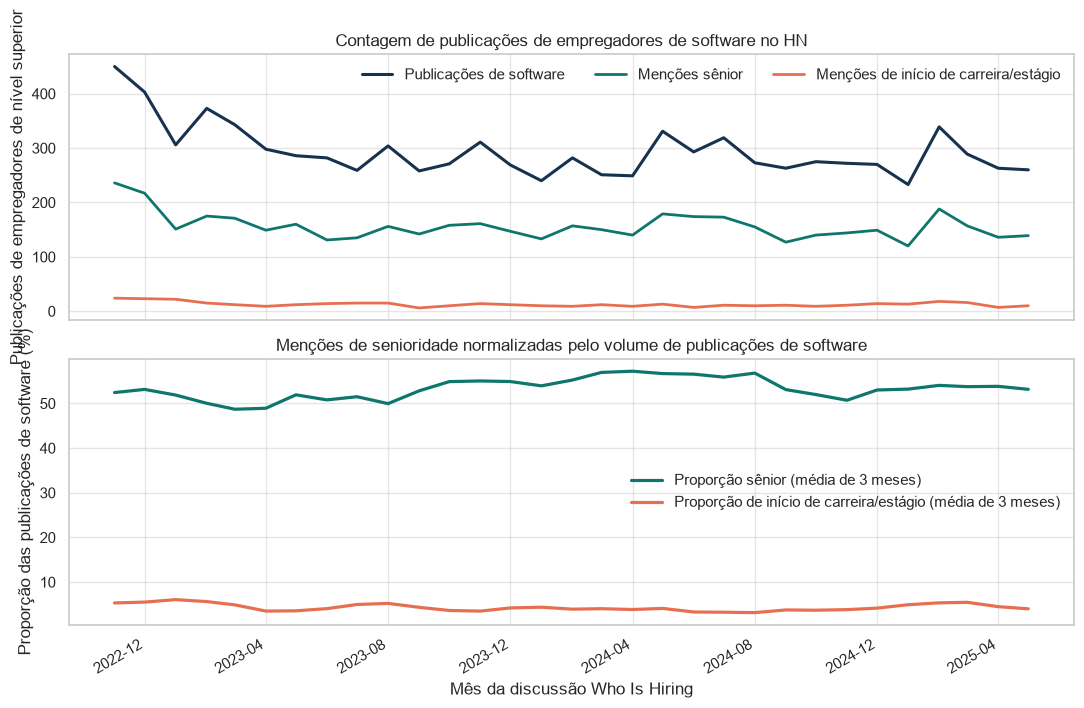

Menções mensais de início de carreira/estágio: 17.5 a 13.0 (-25.7%).
Menções mensais sênior: 183.2 a 148.2 (-19.1%).
Variação da proporção de início de carreira/estágio: -0.11 pontos percentuais; variação da proporção sênior: +3.21 pontos percentuais.
Comentários de nível superior baixados: 10749
Publicações relacionadas a software: 9115


In [6]:
hn = pd.read_csv(
    ROOT / "data" / "processed" / "hn_seniority_monthly.csv",
    parse_dates=["month_start"],
)
hn_method = json.loads(
    (ROOT / "data" / "processed" / "hn_seniority_summary.json").read_text(encoding="utf-8")
)

early, late = hn.head(6), hn.tail(6)
hn_comparison = pd.DataFrame({
    "measure": [
        "Publicações de início de carreira/estágio por mês",
        "Publicações sênior por mês",
        "Proporção de início de carreira/estágio nas publicações de software",
        "Proporção sênior nas publicações de software",
    ],
    "first_6_months": [
        early.junior_intern_mentions.mean(),
        early.senior_mentions.mean(),
        early.junior_intern_share.mean(),
        early.senior_share.mean(),
    ],
    "last_6_months": [
        late.junior_intern_mentions.mean(),
        late.senior_mentions.mean(),
        late.junior_intern_share.mean(),
        late.senior_share.mean(),
    ],
})
hn_comparison["change"] = [
    late.junior_intern_mentions.mean() / early.junior_intern_mentions.mean() - 1,
    late.senior_mentions.mean() / early.senior_mentions.mean() - 1,
    late.junior_intern_share.mean() - early.junior_intern_share.mean(),
    late.senior_share.mean() - early.senior_share.mean(),
]
display(hn_comparison.rename(columns={"measure": "Métrica", "first_6_months": "Primeiros 6 meses", "last_6_months": "Últimos 6 meses", "change": "Variação"}))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(hn.month_start, hn.software_posts, color="#16324f", lw=2.2, label="Publicações de software")
axes[0].plot(hn.month_start, hn.senior_mentions, color="#0f766e", lw=2, label="Menções sênior")
axes[0].plot(hn.month_start, hn.junior_intern_mentions, color="#e76f51", lw=2, label="Menções de início de carreira/estágio")
axes[0].set(title="Contagem de publicações de empregadores de software no HN", ylabel="Publicações de empregadores de nível superior")
axes[0].legend(frameon=False, ncol=3)
axes[1].plot(
    hn.month_start,
    hn.senior_share_3m * 100,
    color="#0f766e",
    lw=2.3,
    label="Proporção sênior (média de 3 meses)",
)
axes[1].plot(
    hn.month_start,
    hn.junior_intern_share_3m * 100,
    color="#e76f51",
    lw=2.3,
    label="Proporção de início de carreira/estágio (média de 3 meses)",
)
axes[1].set(
    title="Menções de senioridade normalizadas pelo volume de publicações de software",
    xlabel="Mês da discussão Who Is Hiring",
    ylabel="Proporção das publicações de software (%)",
)
axes[1].legend(frameon=False)
format_month_axis(axes[1], interval=4)
fig.tight_layout()
plt.show()

junior_count_change = (
    late.junior_intern_mentions.mean() / early.junior_intern_mentions.mean() - 1
) * 100
senior_count_change = (
    late.senior_mentions.mean() / early.senior_mentions.mean() - 1
) * 100
junior_share_change = (
    late.junior_intern_share.mean() - early.junior_intern_share.mean()
) * 100
senior_share_change = (
    late.senior_share.mean() - early.senior_share.mean()
) * 100
print(
    f"Menções mensais de início de carreira/estágio: {early.junior_intern_mentions.mean():.1f} a "
    f"{late.junior_intern_mentions.mean():.1f} ({junior_count_change:.1f}%)."
)
print(
    f"Menções mensais sênior: {early.senior_mentions.mean():.1f} a "
    f"{late.senior_mentions.mean():.1f} ({senior_count_change:.1f}%)."
)
print(
    f"Variação da proporção de início de carreira/estágio: {junior_share_change:+.2f} pontos percentuais; "
    f"variação da proporção sênior: {senior_share_change:+.2f} pontos percentuais."
)
print("Comentários de nível superior baixados:", hn_method["rows"])
print("Publicações relacionadas a software:", hn_method["software_posts"])

### Interpretação e limitações do HN

Dos seis primeiros aos seis últimos meses, as menções mensais de início de carreira/estágio caíram cerca de **25,7%** e as menções sênior caíram cerca de **19,1%**. Após a normalização pelo volume mensal de publicações de software, a proporção de início de carreira/estágio quase não mudou (**−0,11 ponto percentual**), enquanto a proporção sênior aumentou cerca de **3,21 pontos percentuais**.

A conclusão defensável é que o volume de publicações de empregadores no HN diminuiu para os dois grupos, enquanto a composição continuou fortemente voltada a posições sênior e se deslocou um pouco mais para menções sênior. Isso **não** estabelece que todo o mercado de trabalho de software tenha se comportado da mesma forma.

Limitações: o Hacker News é uma comunidade de tecnologia autoselecionada; as marcações por palavras-chave podem não identificar senioridade implícita; um comentário pode anunciar várias vagas; comentários excluídos não estão presentes; e menções não são contagens de empregos ou contratações únicas.

In [7]:
required_artifacts = [
    ROOT / "data" / "processed" / "monthly_regression_dataset.csv",
    ROOT / "data" / "processed" / "model_comparison.csv",
    ROOT / "data" / "processed" / "test_predictions.csv",
    ROOT / "data" / "processed" / "diagnostic_summary.json",
    ROOT / "data" / "processed" / "hn_seniority_monthly.csv",
    ROOT / "data" / "processed" / "hn_seniority_summary.json",
    ROOT / "data" / "processed" / "combined_indeed_hn_monthly.csv",
    ROOT / "model" / "controlled_linear_model.pkl",
]
artifact_check = pd.DataFrame({
    "Artefato": [path.name for path in required_artifacts],
    "Existe": [path.exists() for path in required_artifacts],
})
display(artifact_check)
assert artifact_check["Existe"].all(), "Atualize os dados do HN e execute build_all.py antes da entrega final."

,Artefato,Existe
0,monthly_regression_dataset.csv,True
1,model_comparison.csv,True
2,test_predictions.csv,True
3,diagnostic_summary.json,True
4,hn_seniority_monthly.csv,True
5,hn_seniority_summary.json,True
6,combined_indeed_hn_monthly.csv,True
7,controlled_linear_model.pkl,True


## 7. Reprodutibilidade

Execute a partir de `/genai_jobs`:

```powershell
python -m pip install -r requirements.txt
python fetch_hn_who_is_hiring.py
python build_all.py
python -m streamlit run app.py
```

A busca do HN só é necessária ao atualizar os comentários em cache. O notebook, os resultados processados, o modelo serializado e o aplicativo Streamlit usam a mesma filtragem, as mesmas unidades das variáveis, a mesma avaliação cronológica, a mesma especificação de regressão selecionada, as mesmas regras de senioridade do HN e o mesmo modelo final de implantação.